In [1]:
%load_ext autoreload
%autoreload 2

import sys
import pandas
sys.path.append("..")
#import pandas
import numpy as np
import matplotlib.pyplot as plt
import warnings
from numpy import random
warnings.filterwarnings('ignore')
import os
from pathlib import Path
from scipy.optimize import curve_fit
plotsdir = '/Users/billiemeadowcroft/Dropbox/Collagen/RicardoProject/GithubCode/Data_and_Figures_2026/Fig_Tlife_conditions/Plots/'
#dataout  = '/nfs/scistore15/saricgrp/bmeadowc/Scratch/Collagen/model_strict_tetramer/EquilibriumSeededWorkflow/Plotting/'

import sys

# Check the current recursion limit
current_limit = sys.getrecursionlimit()
print("Current recursion limit:", current_limit)

# Increase the recursion limit
sys.setrecursionlimit(6000)

Current recursion limit: 3000


In [2]:
clrs00 = ['#A10035','#2A0944','lightsalmon','#3FA796','#FEC260','pink','#A10035','#2A0944','#3FA796']
cmap0 = plt.cm.get_cmap('Spectral_r') #YlOrBr
cmap1 = plt.cm.get_cmap('YlOrBr') #YlOrBr
#cmap2 = plt.cm.get_cmap('twilight') #twilight
cmap2 = plt.cm.get_cmap('GnBu') #twilight
cmap3 = plt.cm.get_cmap('BuPu') #twilight
clrs = ['#a6611a','#dfc27d','#80cdc1','#018571','#f5f5f5']
clrs2 = ['#ffffcc','#c7e9b4','#7fcdbb','#41b6c4','#1d91c0','#225ea8','#0c2c84','lightsalmon']
clrs3 = ['#c7e9b4','#7fcdbb','#1d91c0','#225ea8','#0c2c84']
clrs = ['#a6611a','#dfc27d','olive','#80cdc1','#018571','steelblue','slateblue','#0c2c84','lightsalmon']
ClrsRiciChosenHalf = ["#7883acff","#73457aff","#b25268ff","#d49995ff"]


In [3]:
### ---------- Original Data --------- ###
TLifeDenseControl = [1432985.6901671062,2799189.5261354707,4068293.605479009,6929487.412154817,9608369.203749232,17744419.7023999,60659784.20757983]
TLifeDenseControlSTD  = [39384.50459884934,66358.84317330043,122813.13094468458,301665.7186546016,138054.31284285168,114349.62553078415,3577912.0566655914]
Taus_Std = [111.88367031,270.31056655 ,252.95813671,   731.79453038 , 2166.83233744 , 1499.83686007 , 5753.28351424]
Taus_Av = [3443.06650729 , 4768.29772279 , 6640.75435437 , 9617.67637145, 15687.20224171 ,30642.58077272, 91028.7048401]

#from : Scratch/Collagen/RiccyProject/Revision2/Stretch-AddDenseControl/Plotting/PlottingStress_CLEAN.ipynb
# and : Scratch/Collagen/RiccyProject/Revision2/Assembly-AddDenseControl/Plotting/Turnover_BondSample_final.ipynb

## ------------- Smaller density data ------------- ##
TLife_HalfDensity = [19023144.387669597, 11211219.580677658, 8269915.976067151, 4428032.285359419, 3440558.8137687556, 1680056.9265104067] #76672448.91155781, 

TLife_HalfDensitySTD = [312185.2531295979, 161920.6159397739, 42307.45455047196, 171672.88664936714, 94189.10811474871, 33416.27196498858] #4075961.3196079284, 
# reverse the order of the elements
TLife_HalfDensity = TLife_HalfDensity[::-1]
TLife_HalfDensitySTD = TLife_HalfDensitySTD[::-1]

TLife_3QuartersDensity = [61144012.93800663, 17419731.638644286, 9601611.170126246, 6973548.430347822, 3886761.604273859, 2822455.5592132583, 1469318.313876138]
TLife_3QuartersDensitySTD = [8722751.726070553, 155857.92031160556, 63203.13475621172, 50520.32304531655, 103292.71386950296, 14340.185378188722, 44486.173770335314]
TLife_3QuartersDensity = TLife_3QuartersDensity[::-1]
TLife_3QuartersDensitySTD = TLife_3QuartersDensitySTD[::-1]
# For now this is a placeholder, sims still running
Taus_HalfDensity = [6.81494365e+04, 1.98594075e+04, 1.26972328e+04, 7.95801420e+03, 5.64981685e+03, 3.27234246e+03] #9.36631874e+07, 
Taus_HalfDensitySTD = [5.42339013e+04, 4.19465401e+03 ,7.02031633e+02, 2.13672757e+03 ,1.54438640e+03 ,2.54932325e+02] #1.32289839e+08 ,
Taus_HalfDensity = Taus_HalfDensity[::-1]
Taus_HalfDensitySTD = Taus_HalfDensitySTD[::-1]
Taus_3QuartersDensity = [105094.08566633,19414.49286818,18679.27850103,13889.88120684,7419.65430992,4892.0771886,3235.82232726]
Taus_3QuartersDensitySTD = [10183.99891465,13736.86297059,3405.1287054,2105.25471744,802.33792709,435.7165371,738.26284271]
Taus_3QuartersDensity = Taus_3QuartersDensity[::-1]
Taus_3QuartersDensitySTD = Taus_3QuartersDensitySTD[::-1]
### ---------- Measuring lifetime post stretch-relax --------- ###
TlifePostRel =  [43569478.59071621, 15470282.570977237, 8323981.789098067, 6750354.187204916, 3367844.338826594, 2367768.884301441, 1356395.0914849201] #, 1156739.0119705996
TlifePostRelSTD = [1015896.2324803956, 361962.5454262942, 60337.80565210385, 650186.8102591587, 150093.8600750144, 1904.0829952887725, 0.0] #, 13940.49433619564

#invert TlifePostRel, so that the elements go backwards
TlifePostRel = TlifePostRel[::-1]
TlifePostRelSTD = TlifePostRelSTD[::-1]

#from : Scratch/Collagen/RiccyProject/Revision2/Stretch-AddDenseControl/Plotting/Turnover_BondSample_final.ipynb

### ---------- Kappa (bond) = 1.0 --------- ###
# for MPs = [0.01,0.09,0.81]
TlifeKapp1 = [52094433.367664464, 6149335.896683776, 893996.5601895632]
TlifeKapp1STD = [1084021.030990202, 159424.0412016992, 6055.497805482523]
TrelKapp1 = [85967.57087939 ,14017.93701023 , 3580.81329977] 
TrelKapp1STD = [16968.3819448  ,  665.34329075   ,  0.        ]
### ---------- Krod (molecule) = 200 --------- ###
# for MPs = [0.01,0.09,0.81]
TlifeKrod200 = [62289751.86400736, 6922423.803302859, 1226349.9419327937]
TlifeKrod200STD = [2465441.17372322, 165838.33520944839, 46796.8911249203]
TrelKrod200 = [99085.72646731 ,11207.58503031 , 2624.08384712] 
TrelKrod200STD = [23265.85948729  , 691.60020299 ,  247.56319414]

# from: Scratch/Collagen/RiccyProject/Revision2/Stretch-AddDenseControl/Plotting/PlottingStress_Params.ipynb
# and : Scratch/Collagen/RiccyProject/Revision2/Assembly-AddDenseControl/Plotting/Turnover_BondSample_Params.ipynb




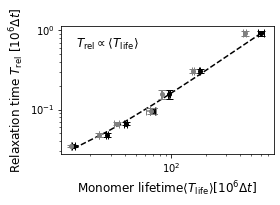

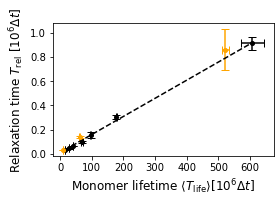

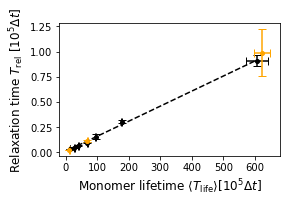

In [4]:
figPR,axPR = plt.subplots(1,figsize = (4.,2.7))
x1,y1 = np.array(np.divide(TLifeDenseControl,10**5)),np.array(np.divide(Taus_Av,10**5))
m1,b1 = np.polyfit(x1,y1,1)
x11 = x1.reshape(-1,1)
a1,_,_,_ = np.linalg.lstsq(x11, y1)
axPR.errorbar(np.divide(TLifeDenseControl,10**5),np.divide(Taus_Av,10**5),yerr = np.divide(Taus_Std,10**5), xerr = np.divide(TLifeDenseControlSTD,10**5), color = 'black',linestyle = '',marker = 'o',markersize = 4,capsize = 4)
axPR.plot(x1,np.divide(m1*x1+b1,1),color = 'black',linestyle = '--',label = r'$\tau_{rel} = 5\cdot 10^{-4}\langle T_{\mathrm{life}}\rangle$')
axPR.errorbar(np.divide(TlifePostRel,10**5),np.divide(Taus_Av,10**5),yerr = np.divide(Taus_Std,10**5), xerr = np.divide(TlifePostRelSTD,10**5), color = 'grey',linestyle = '',marker = 'o',markersize = 4,capsize = 4)
axPR.set_xlabel(r'Monomer lifetime$\langle T_{\mathrm{life}}\rangle [10^6\Delta t]$',fontsize = 12)
axPR.set_ylabel(r"Relaxation time $T_{\mathrm{rel}}$ [$10^6\Delta t$]",fontsize = 12)

text = r'$\tau_{rel} = 5\cdot 10^{-4}\langle T_{\mathrm{life}}\rangle$'
text = r'$T_{\mathrm{rel}} \propto \langle T_{\mathrm{life}}\rangle$'
axPR.text(15,0.6,text,color = 'black',fontsize = 12)
#---- log-log axis---#
axPR.set_xscale('log')
axPR.set_yscale('log')

#ax.set_xticks([0,200,400,600],['0','200','400','600'])
#ax.set_yticks([0,0.2,0.4,0.6,0.8],['0','0.2','0.4','0.6','0.8'])

figPR.tight_layout()
figPR.savefig(plotsdir + 'MasterTlifeTrelax_PostRelaxation.png',dpi = 300)

figKapp,axKapp = plt.subplots(1,figsize = (4.,2.7))
axKapp.errorbar(np.divide(TLifeDenseControl,10**5),np.divide(Taus_Av,10**5),yerr = np.divide(Taus_Std,10**5), xerr = np.divide(TLifeDenseControlSTD,10**5), color = 'black',linestyle = '',marker = 'o',markersize = 4,capsize = 4)

axKapp.errorbar(np.divide(TlifeKapp1,10**5),np.divide(TrelKapp1,10**5),yerr = np.divide(TrelKapp1STD,10**5), xerr = np.divide(TlifeKapp1STD,10**5), color = 'orange',linestyle = '',marker = 'o',markersize = 4,capsize = 4)
axKapp.plot(x1,np.divide(m1*x1+b1,1),color = 'black',linestyle = '--',label = r'$\tau_{rel} = 5\cdot 10^{-4}\langle T_{\mathrm{life}}\rangle$')
axKapp.set_xlabel(r'Monomer lifetime $\langle T_{\mathrm{life}}\rangle [10^6\Delta t]$',fontsize = 12)
axKapp.set_ylabel(r"Relaxation time $T_{\mathrm{rel}}$ [$10^6\Delta t$]",fontsize = 12)


figKapp.tight_layout()
figKapp.savefig(plotsdir + 'MasterTlifeTrelax_Kappa.png',dpi = 300)

figKrod,axKrod = plt.subplots(1,figsize = (4.,2.7))
axKrod.errorbar(np.divide(TLifeDenseControl,10**5),np.divide(Taus_Av,10**5),yerr = np.divide(Taus_Std,10**5), xerr = np.divide(TLifeDenseControlSTD,10**5), color = 'black',linestyle = '',marker = 'o',markersize = 4,capsize = 4)

axKrod.errorbar(np.divide(TlifeKrod200,10**5),np.divide(TrelKrod200,10**5),yerr = np.divide(TrelKrod200STD,10**5), xerr = np.divide(TlifeKrod200STD,10**5), color = 'orange',linestyle = '',marker = 'o',markersize = 4,capsize = 4)
axKrod.plot(x1,np.divide(m1*x1+b1,1),color = 'black',linestyle = '--',label = r'$\tau_{rel} = 5\cdot 10^{-4}\langle T_{\mathrm{life}}\rangle$')
axKrod.set_xlabel(r'Monomer lifetime $\langle T_{\mathrm{life}}\rangle [10^5\Delta t]$',fontsize = 12)
axKrod.set_ylabel(r"Relaxation time $T_{\mathrm{rel}}$ [$10^5\Delta t$]",fontsize = 12)

figKrod.tight_layout()
figKrod.savefig(plotsdir + 'MasterTlifeTrelax_Krod.png',dpi = 300)




[1680056.9265104067, 3440558.8137687556, 4428032.285359419, 8269915.976067151, 11211219.580677658, 19023144.387669597]
[3272.34246, 5649.81685, 7958.0142, 12697.2328, 19859.4075, 68149.4365]


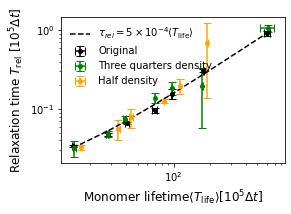

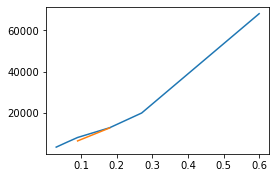

In [9]:
figConc,axConc = plt.subplots(1,figsize = (4.,2.7))


axConc.errorbar(np.divide(TLifeDenseControl,10**5),np.divide(Taus_Av,10**5),yerr = np.divide(Taus_Std,10**5), xerr = np.divide(TLifeDenseControlSTD,10**5), color = 'black',linestyle = '',marker = 'o',markersize = 4,capsize = 4,label = "Original")
axConc.errorbar(np.divide(TLife_3QuartersDensity,10**5),np.divide(Taus_3QuartersDensity,10**5),yerr = np.divide(Taus_3QuartersDensitySTD,10**5), xerr = np.divide(TLife_3QuartersDensitySTD,10**5), color = 'green',linestyle = '',marker = 'o',markersize = 4,capsize = 4,label = "Three quarters density")
axConc.errorbar(np.divide(TLife_HalfDensity,10**5),np.divide(Taus_HalfDensity,10**5),yerr = np.divide(Taus_HalfDensitySTD,10**5), xerr = np.divide(TLife_HalfDensitySTD,10**5), color = 'orange',linestyle = '',marker = 'o',markersize = 4,capsize = 4,label = "Half density")
axConc.plot(x1,np.divide(m1*x1+b1,1),color = 'black',linestyle = '--',label = r'$\tau_{rel} = 5\times 10^{-4}\langle T_{\mathrm{life}}\rangle$')

axConc.set_xlabel(r'Monomer lifetime$\langle T_{\mathrm{life}}\rangle [10^5\Delta t]$',fontsize = 12)
axConc.set_ylabel(r"Relaxation time $T_{\mathrm{rel}}$ [$10^5\Delta t$]",fontsize = 12)
axConc.set_yscale('log')
axConc.set_xscale('log')
axConc.legend(frameon = False)

print(TLife_HalfDensity)
print(Taus_HalfDensity)
1.26e4
6.29e3
Taus_Other_HalfDensity = [6.29e3,1.26e4]
MPs = [0.09,0.18]
MPs_Norm = [0.03,0.06,0.09,0.18,0.27,0.6]
fig,ax = plt.subplots(1,figsize = (4.,2.7))
ax.plot(MPs_Norm,Taus_HalfDensity)
ax.plot(MPs,Taus_Other_HalfDensity)